# MediScan — Day 03: Data Augmentation

## Objective

Apply data augmentation techniques to the training images:

- Random Horizontal Flip
- Random Rotation
- Color Jitter
- Random Affine Transformation

Also visualize original and augmented MRI images.

## Dataset

Brain MRI Classification Dataset

Classes:
- Glioma
- Meningioma
- No Tumor
- Pituitary

## Previous Day

Day 2 completed the stratified 70/15/15 dataset split:

- Train: 5040
- Validation: 1080
- Test: 1080
- Total: 7200

## Day 3 Tasks

1. Load the Day 2 processed dataset
2. Define training augmentation pipeline
3. Apply random horizontal flips
4. Apply random rotations
5. Apply color jitter
6. Apply random affine transformations
7. Visualize augmentation effects
8. Verify augmented tensor output
9. Save augmentation visualizations
10. Generate Day 3 summary

In [4]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os

print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'New Folder', 'Sagar.jpg', 'IMG-20250906-WA0002.jpg', 'IMG-20251110-WA0001.jpg', 'OKIE DOKIE APP', 'Knowledge Base', 'IMG_20260330_181523.png', 'Nishu Bhabhi', 'IMG-20260527-WA0003.jpg', 'IMG-20260527-WA0002.jpg', 'IMG-20260527-WA0001.jpg', 'project ppt ', 'DATA ANALYST INTERNSHIP ', 'ey1.pdf', 'ey2.pdf', 'IMG_20260623_095508.jpg', 'Resume_Enhanced.pdf', 'ibm_offer_letter.pdf', 'IMG_20260709_084613.jpg', 'IMG_20260709_084627.jpg', 'IMG_20260709_084720.jpg', 'IBM_Certificate.pdf', 'Ticket_Categorizer_Submission.pdf', 'Sagar_Sharma_Resume.pdf', 'archive.zip']


In [7]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    if (
        'train.csv' in files
        or 'val.csv' in files
        or 'test.csv' in files
        or 'class_to_idx.json' in files
    ):
        print("\nFOUND:")
        print(root)
        print("Files:", files)

In [8]:
import os

for root, dirs, files in os.walk('/content'):
    if (
        'train.csv' in files
        or 'val.csv' in files
        or 'test.csv' in files
        or 'class_to_idx.json' in files
    ):
        print("\nFOUND:")
        print(root)
        print("Files:", files)

In [9]:
import zipfile
from pathlib import Path

zip_path = Path("/content/drive/MyDrive/archive.zip")

print("ZIP exists:", zip_path.exists())

if zip_path.exists():
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        files = zip_ref.namelist()

    print("Total files in ZIP:", len(files))
    print("\nFirst 20 files:")
    for file in files[:20]:
        print(file)

ZIP exists: True
Total files in ZIP: 7200

First 20 files:
Testing/glioma/Te-gl_1.jpg
Testing/glioma/Te-gl_10.jpg
Testing/glioma/Te-gl_100.jpg
Testing/glioma/Te-gl_101.jpg
Testing/glioma/Te-gl_102.jpg
Testing/glioma/Te-gl_103.jpg
Testing/glioma/Te-gl_104.jpg
Testing/glioma/Te-gl_105.jpg
Testing/glioma/Te-gl_106.jpg
Testing/glioma/Te-gl_107.jpg
Testing/glioma/Te-gl_108.jpg
Testing/glioma/Te-gl_109.jpg
Testing/glioma/Te-gl_11.jpg
Testing/glioma/Te-gl_110.jpg
Testing/glioma/Te-gl_111.jpg
Testing/glioma/Te-gl_112.jpg
Testing/glioma/Te-gl_113.jpg
Testing/glioma/Te-gl_114.jpg
Testing/glioma/Te-gl_115.jpg
Testing/glioma/Te-gl_116.jpg


In [10]:
import zipfile
from pathlib import Path

zip_path = Path("/content/drive/MyDrive/archive.zip")
extract_path = Path("/content/MediScan")

extract_path.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")
print("Dataset location:", extract_path)

Dataset extracted successfully!
Dataset location: /content/MediScan


In [11]:
from pathlib import Path

dataset_path = Path("/content/MediScan")

for item in dataset_path.iterdir():
    print(item.name)

Testing
Training


In [12]:
for split in ["Training", "Testing"]:

    split_path = dataset_path / split

    print(f"\n{split}")
    print("-" * 30)

    for class_folder in sorted(split_path.iterdir()):
        if class_folder.is_dir():
            image_count = len(list(class_folder.glob("*")))
            print(
                f"{class_folder.name}: "
                f"{image_count} images"
            )


Training
------------------------------
glioma: 1400 images
meningioma: 1400 images
notumor: 1400 images
pituitary: 1400 images

Testing
------------------------------
glioma: 400 images
meningioma: 400 images
notumor: 400 images
pituitary: 400 images


In [14]:
import pandas as pd
import numpy as np

from pathlib import Path
from sklearn.model_selection import train_test_split

In [15]:
# Dataset location
DATASET_DIR = Path("/content/MediScan")

TRAINING_DIR = DATASET_DIR / "Training"
TESTING_DIR = DATASET_DIR / "Testing"

print("Training path:", TRAINING_DIR)
print("Testing path:", TESTING_DIR)

print("\nTraining exists:", TRAINING_DIR.exists())
print("Testing exists:", TESTING_DIR.exists())

Training path: /content/MediScan/Training
Testing path: /content/MediScan/Testing

Training exists: True
Testing exists: True


In [16]:
# ============================================
# Create Dataset Manifest
# ============================================

classes = [
    "glioma",
    "meningioma",
    "notumor",
    "pituitary"
]

records = []

# Training images
for class_name in classes:

    class_dir = TRAINING_DIR / class_name

    for image_path in class_dir.glob("*"):

        if image_path.is_file():

            records.append({
                "image_path": str(image_path),
                "label": class_name,
                "source": "Training"
            })


# Testing images
for class_name in classes:

    class_dir = TESTING_DIR / class_name

    for image_path in class_dir.glob("*"):

        if image_path.is_file():

            records.append({
                "image_path": str(image_path),
                "label": class_name,
                "source": "Testing"
            })


df = pd.DataFrame(records)

print("Total images:", len(df))
print("\nClass distribution:")
print(df["label"].value_counts())

print("\nSource distribution:")
print(df["source"].value_counts())

Total images: 7200

Class distribution:
label
glioma        1800
meningioma    1800
notumor       1800
pituitary     1800
Name: count, dtype: int64

Source distribution:
source
Training    5600
Testing     1600
Name: count, dtype: int64


In [17]:
# ============================================
# Stratified 70/15/15 Split
# ============================================

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

# Reset indexes
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))
print("Total:", len(train_df) + len(val_df) + len(test_df))

Train: 5040
Validation: 1080
Test: 1080
Total: 7200


In [18]:
# ============================================
# Verify Stratified Split
# ============================================

print("TRAIN")
print(train_df["label"].value_counts().sort_index())

print("\nVALIDATION")
print(val_df["label"].value_counts().sort_index())

print("\nTEST")
print(test_df["label"].value_counts().sort_index())

TRAIN
label
glioma        1260
meningioma    1260
notumor       1260
pituitary     1260
Name: count, dtype: int64

VALIDATION
label
glioma        270
meningioma    270
notumor       270
pituitary     270
Name: count, dtype: int64

TEST
label
glioma        270
meningioma    270
notumor       270
pituitary     270
Name: count, dtype: int64


In [19]:
# ============================================
# Create Processed Data Directory
# ============================================

PROCESSED_DIR = Path(
    "/content/drive/MyDrive/MediScan/data/processed"
)

PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Created:", PROCESSED_DIR)

Created: /content/drive/MyDrive/MediScan/data/processed


In [20]:
# ============================================
# Save Split CSV Files
# ============================================

train_df.to_csv(
    PROCESSED_DIR / "train.csv",
    index=False
)

val_df.to_csv(
    PROCESSED_DIR / "val.csv",
    index=False
)

test_df.to_csv(
    PROCESSED_DIR / "test.csv",
    index=False
)

print("Saved:")
print("- train.csv")
print("- val.csv")
print("- test.csv")

Saved:
- train.csv
- val.csv
- test.csv


In [21]:
# ============================================
# Save Class Mapping
# ============================================

import json

class_to_idx = {
    "glioma": 0,
    "meningioma": 1,
    "notumor": 2,
    "pituitary": 3
}

with open(
    PROCESSED_DIR / "class_to_idx.json",
    "w"
) as f:

    json.dump(
        class_to_idx,
        f,
        indent=4
    )

print(class_to_idx)

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [22]:
# ============================================
# Verify Processed Files
# ============================================

print("Files inside processed directory:\n")

for file in sorted(PROCESSED_DIR.iterdir()):
    print(file.name)

Files inside processed directory:

class_to_idx.json
test.csv
train.csv
val.csv


In [23]:
from pathlib import Path
import os
import json
import pandas as pd

PROJECT_DIR = Path(
    "/content/drive/MyDrive/MediScan"
)

os.chdir(PROJECT_DIR)

print("Current working directory:")
print(os.getcwd())

Current working directory:
/content/drive/MyDrive/MediScan


In [24]:
train_df = pd.read_csv(
    "data/processed/train.csv"
)

val_df = pd.read_csv(
    "data/processed/val.csv"
)

test_df = pd.read_csv(
    "data/processed/test.csv"
)

with open(
    "data/processed/class_to_idx.json",
    "r"
) as f:

    class_to_idx = json.load(f)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nClass mapping:")
print(class_to_idx)

Train: 5040
Validation: 1080
Test: 1080

Class mapping:
{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [26]:
print("Class mapping:")
print(class_to_idx)

Class mapping:
{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


# Day 3 — Data Augmentation

Today we will implement the data augmentation techniques specified in the project brief:

- Random Flips
- Random Rotations
- Color Jitter
- Affine Transformations

We will also visualize the original and augmented MRI images.

Data augmentation will be applied to the training data only.

In [28]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import transforms

In [29]:
train_augmentation = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(
        degrees=15
    ),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10,
        hue=0.02
    ),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05),
        shear=5
    ),

    transforms.ToTensor()
])

print(train_augmentation)

Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.85, 1.15), contrast=(0.85, 1.15), saturation=(0.9, 1.1), hue=(-0.02, 0.02))
    RandomAffine(degrees=[0.0, 0.0], translate=(0.05, 0.05), scale=(0.95, 1.05), shear=[-5.0, 5.0])
    ToTensor()
)


In [30]:
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

print(eval_transform)

Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


## Visualizing Data Augmentation

We will select one representative MRI image from each class and visualize:

1. Original Image
2. Random Horizontal Flip
3. Random Rotation
4. Color Jitter
5. Random Affine Transformation

This helps us visually verify the effect of each augmentation technique.

In [31]:
# ============================================
# Select one image from each class
# ============================================

selected_rows = []

for class_name in sorted(
    class_to_idx.keys(),
    key=lambda x: class_to_idx[x]
):

    row = train_df[
        train_df["label"] == class_name
    ].iloc[0]

    selected_rows.append(row)

selected_df = pd.DataFrame(selected_rows)

print("Selected images:")
display(
    selected_df[["image_path", "label"]]
)

Selected images:


,image_path,label
5,/content/MediScan/Training/glioma/Tr-gl_857.jpg,glioma
11,/content/MediScan/Training/meningioma/Tr-me_41...,meningioma
0,/content/MediScan/Training/notumor/Tr-no_626.jpg,notumor
1,/content/MediScan/Testing/pituitary/Te-pi_3.jpg,pituitary


In [32]:
# ============================================
# Load the selected MRI images
# ============================================

original_images = []

for _, row in selected_df.iterrows():

    image = Image.open(
        row["image_path"]
    ).convert("RGB")

    original_images.append(image)

print(
    "Number of images:",
    len(original_images)
)

print(
    "Original image size:",
    original_images[0].size
)

Number of images: 4
Original image size: (512, 512)


In [33]:
# ============================================
# Individual Augmentation Transforms
# ============================================

flip_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=1.0)
])


rotation_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(
        degrees=15
    )
])


color_jitter_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10,
        hue=0.02
    )
])


affine_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05),
        shear=5
    )
])

print("Individual augmentation transforms created.")

Individual augmentation transforms created.


## Original vs Augmented Images

Each row represents one MRI class.

Columns:

Original → Random Flip → Random Rotation → Color Jitter → Random Affine

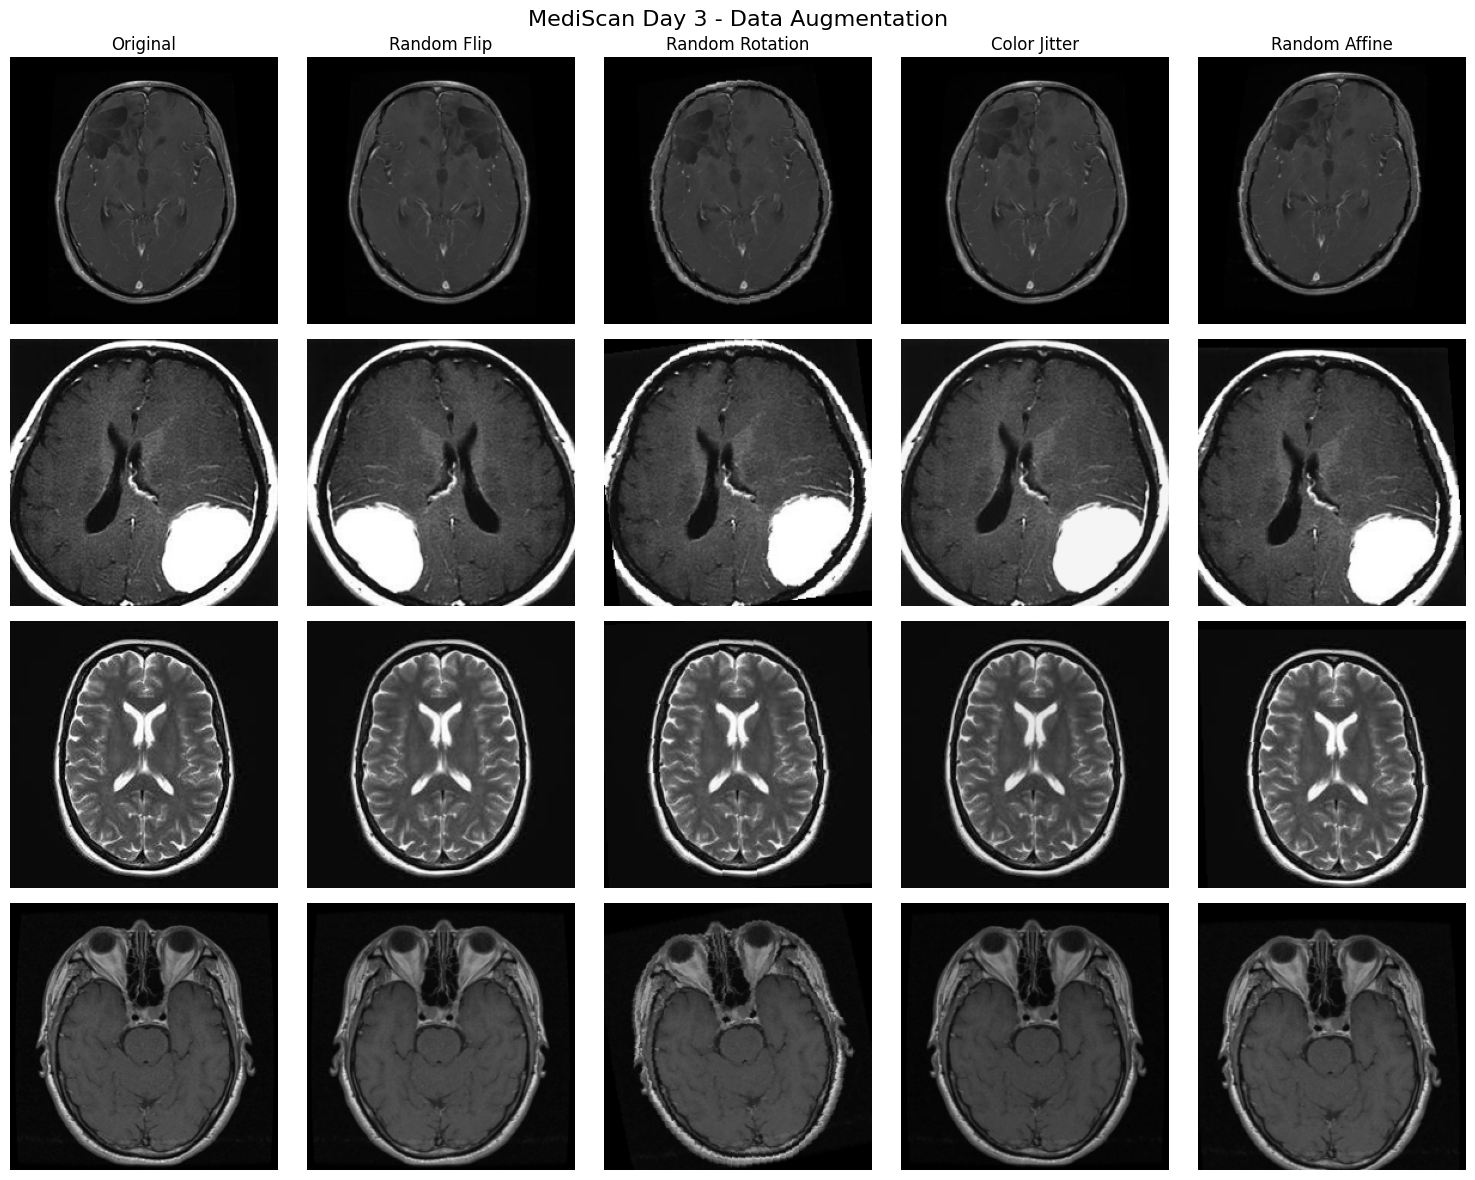

In [34]:
# ============================================
# Visualize Individual Augmentations
# ============================================

def apply_with_seed(transform, image, seed):
    torch.manual_seed(seed)
    return transform(image)


fig, axes = plt.subplots(
    len(original_images),
    5,
    figsize=(15, 12)
)


column_titles = [
    "Original",
    "Random Flip",
    "Random Rotation",
    "Color Jitter",
    "Random Affine"
]


for row_idx, (
    image,
    (_, row)
) in enumerate(
    zip(
        original_images,
        selected_df.iterrows()
    )
):

    augmented_images = [

        image.resize((224, 224)),

        apply_with_seed(
            flip_transform,
            image,
            42 + row_idx
        ),

        apply_with_seed(
            rotation_transform,
            image,
            52 + row_idx
        ),

        apply_with_seed(
            color_jitter_transform,
            image,
            62 + row_idx
        ),

        apply_with_seed(
            affine_transform,
            image,
            72 + row_idx
        )
    ]


    for col_idx, aug_image in enumerate(
        augmented_images
    ):

        axes[row_idx, col_idx].imshow(
            aug_image
        )

        axes[row_idx, col_idx].axis("off")


        if row_idx == 0:
            axes[
                row_idx,
                col_idx
            ].set_title(
                column_titles[col_idx]
            )


    axes[row_idx, 0].set_ylabel(
        row["label"],
        fontsize=11
    )


plt.suptitle(
    "MediScan Day 3 - Data Augmentation",
    fontsize=16
)

plt.tight_layout()

plt.show()

In [35]:
# ============================================
# Save Day 3 Augmentation Visualization
# ============================================

from pathlib import Path

FIGURES_DIR = Path(
    "/content/drive/MyDrive/MediScan/figures"
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

output_path = (
    FIGURES_DIR /
    "day3_augmentation_comparison.png"
)

fig.savefig(
    output_path,
    dpi=150,
    bbox_inches="tight"
)

print("Visualization saved successfully!")
print(output_path)

Visualization saved successfully!
/content/drive/MyDrive/MediScan/figures/day3_augmentation_comparison.png


In [36]:
# ============================================
# Verify Saved Visualization
# ============================================

print("File exists:", output_path.exists())

if output_path.exists():
    print(
        "File size:",
        round(output_path.stat().st_size / 1024, 2),
        "KB"
    )

File exists: True
File size: 1853.42 KB


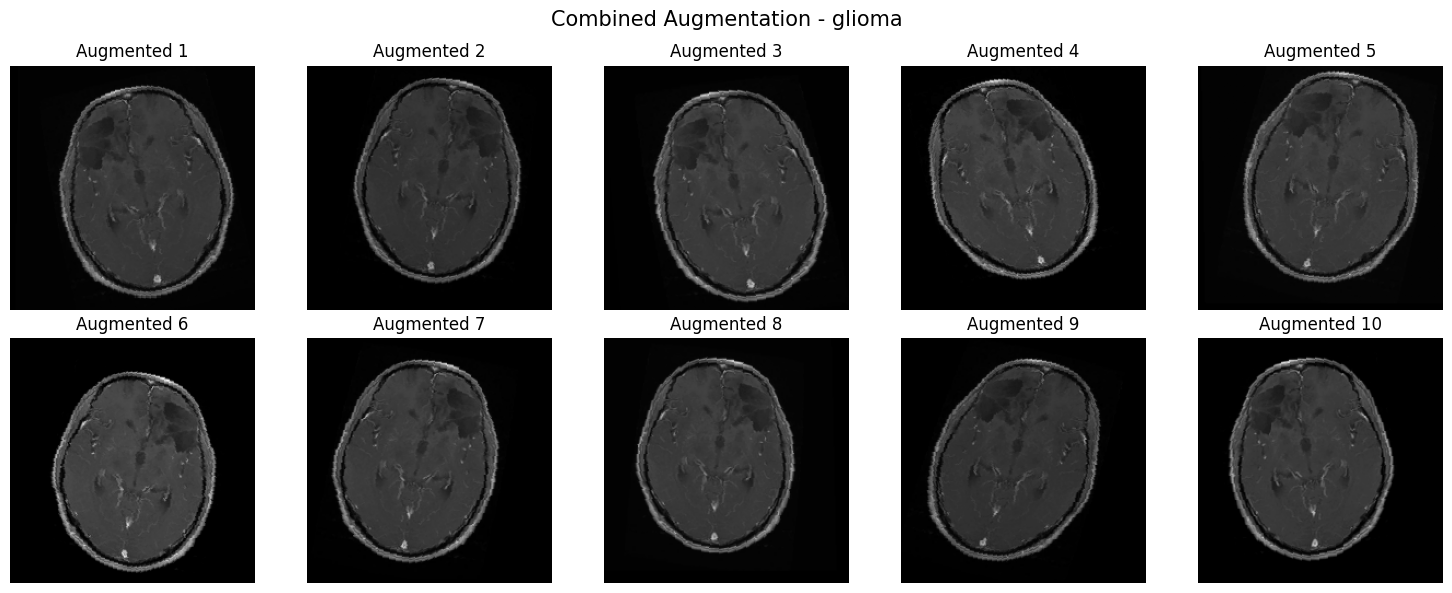

In [37]:
# ============================================
# Combined Augmentation Samples
# ============================================

sample_image = original_images[0]
sample_label = selected_df.iloc[0]["label"]

fig2, axes2 = plt.subplots(
    2,
    5,
    figsize=(15, 6)
)

for i, ax in enumerate(axes2.flat):

    torch.manual_seed(42 + i)

    augmented = train_augmentation(
        sample_image
    )

    display_image = (
        augmented
        .permute(1, 2, 0)
        .numpy()
    )

    display_image = np.clip(
        display_image,
        0,
        1
    )

    ax.imshow(display_image)
    ax.axis("off")
    ax.set_title(
        f"Augmented {i + 1}"
    )

plt.suptitle(
    f"Combined Augmentation - {sample_label}",
    fontsize=15
)

plt.tight_layout()

plt.show()

In [38]:
# ============================================
# Save Combined Augmentation Visualization
# ============================================

combined_output_path = (
    FIGURES_DIR /
    "day3_combined_augmentation_samples.png"
)

fig2.savefig(
    combined_output_path,
    dpi=150,
    bbox_inches="tight"
)

print("Combined visualization saved!")
print(combined_output_path)

Combined visualization saved!
/content/drive/MyDrive/MediScan/figures/day3_combined_augmentation_samples.png


In [39]:
# ============================================
# Final Augmentation Verification
# ============================================

torch.manual_seed(42)

augmented_tensor = train_augmentation(
    original_images[0]
)

print("Shape:", augmented_tensor.shape)
print("Dtype:", augmented_tensor.dtype)
print("Min:", augmented_tensor.min().item())
print("Max:", augmented_tensor.max().item())

Shape: torch.Size([3, 224, 224])
Dtype: torch.float32
Min: 0.0
Max: 0.8039215803146362


In [40]:
# ============================================
# Final Day 3 Verification
# ============================================

assert augmented_tensor.shape == (
    3,
    224,
    224
)

assert augmented_tensor.dtype == torch.float32

assert 0.0 <= augmented_tensor.min().item() <= 1.0

assert 0.0 <= augmented_tensor.max().item() <= 1.0

print("========================================")
print("DAY 3 AUGMENTATION VERIFICATION PASSED")
print("========================================")

DAY 3 AUGMENTATION VERIFICATION PASSED


In [41]:
from pathlib import Path

PROJECT_DIR = Path(
    "/content/drive/MyDrive/MediScan"
)

print("=== DAY 3 FILE CHECK ===\n")

files_to_check = [
    "data/processed/train.csv",
    "data/processed/val.csv",
    "data/processed/test.csv",
    "data/processed/class_to_idx.json",
    "figures/day3_augmentation_comparison.png",
    "figures/day3_combined_augmentation_samples.png",
    "reports/day3_summary.md"
]

for file in files_to_check:
    path = PROJECT_DIR / file

    if path.exists():
        print("✅", file)
    else:
        print("❌", file)

=== DAY 3 FILE CHECK ===

✅ data/processed/train.csv
✅ data/processed/val.csv
✅ data/processed/test.csv
✅ data/processed/class_to_idx.json
✅ figures/day3_augmentation_comparison.png
✅ figures/day3_combined_augmentation_samples.png
❌ reports/day3_summary.md


In [42]:
from pathlib import Path

REPORTS_DIR = Path(
    "/content/drive/MyDrive/MediScan/reports"
)

REPORTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

summary = """
# MediScan — Day 3: Data Augmentation

## Objective

Implement and verify the data augmentation techniques required for the MediScan project.

## Augmentation Techniques

- Random Horizontal Flip
- Random Rotation
- Color Jitter
- Random Affine Transformation

## Dataset Split

| Split | Images |
|---|---:|
| Training | 5040 |
| Validation | 1080 |
| Testing | 1080 |
| Total | 7200 |

## Augmentation Pipeline

Images are resized to 224 × 224 and then processed using the training augmentation pipeline:

Resize
→ Random Horizontal Flip
→ Random Rotation
→ Color Jitter
→ Random Affine
→ ToTensor

## Verification

Augmented image tensor:

- Shape: 3 × 224 × 224
- Dtype: float32
- Pixel values: within [0, 1]

Final verification:

DAY 3 AUGMENTATION VERIFICATION PASSED

## Visualizations

- day3_augmentation_comparison.png
- day3_combined_augmentation_samples.png

## Next Step

Day 4 — Custom Dataset and DataLoader setup.
"""

summary_path = REPORTS_DIR / "day3_summary.md"

summary_path.write_text(
    summary.strip(),
    encoding="utf-8"
)

print("Day 3 summary saved successfully!")
print(summary_path)

Day 3 summary saved successfully!
/content/drive/MyDrive/MediScan/reports/day3_summary.md


In [43]:
from pathlib import Path

PROJECT_DIR = Path(
    "/content/drive/MyDrive/MediScan"
)

print("=== DAY 3 FILE CHECK ===\n")

files_to_check = [
    "data/processed/train.csv",
    "data/processed/val.csv",
    "data/processed/test.csv",
    "data/processed/class_to_idx.json",
    "figures/day3_augmentation_comparison.png",
    "figures/day3_combined_augmentation_samples.png",
    "reports/day3_summary.md"
]

for file in files_to_check:
    path = PROJECT_DIR / file

    if path.exists():
        print("✅", file)
    else:
        print("❌", file)

=== DAY 3 FILE CHECK ===

✅ data/processed/train.csv
✅ data/processed/val.csv
✅ data/processed/test.csv
✅ data/processed/class_to_idx.json
✅ figures/day3_augmentation_comparison.png
✅ figures/day3_combined_augmentation_samples.png
✅ reports/day3_summary.md
